Convolutional Neural Networks (CNNs) are widely used in computer vision tasks such as image classification, object detection, and image segmentation. Instead of training models from scratch, industries often use pretrained CNN models that are trained on large datasets such as ImageNet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

In [2]:
# pretrained VGG16 model
model = VGG16(weights='imagenet')

# model summary
model.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Load image
img_path = "/content/drive/MyDrive/catsvsdogs/test/dogs/dog.100.jpg"

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

print("Image shape:", img_array.shape)

Image shape: (1, 224, 224, 3)


##Loaded Image
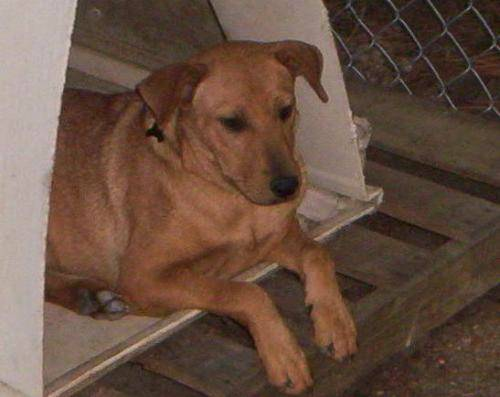

In [4]:
layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name][:1]

feature_model = Model(inputs=model.input, outputs=layer_outputs)

feature_maps = feature_model.predict(img_array)

print("Feature map shape:", feature_maps[0].shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Feature map shape: (224, 224, 64)


Feature map shape: (224, 224, 64)


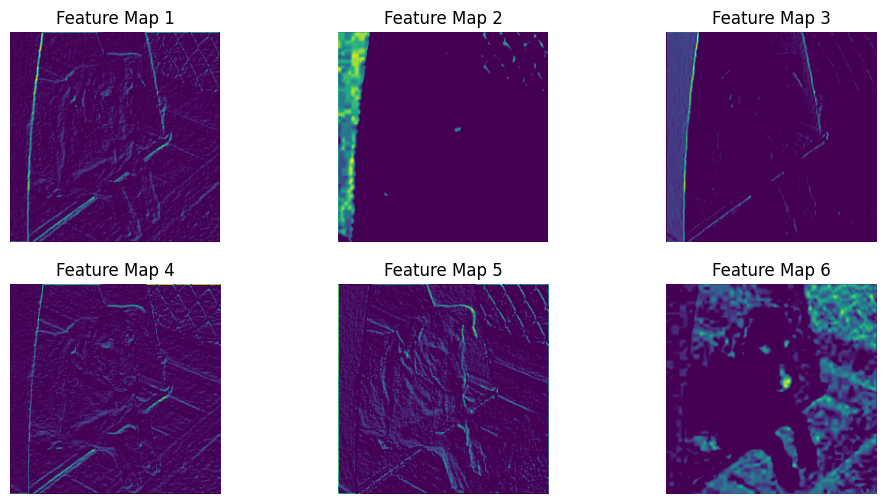

In [7]:
feature_map = feature_maps[0]

print("Feature map shape:", feature_map.shape)

plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_map[:,:,i], cmap='viridis')
    plt.axis("off")
    plt.title("Feature Map " + str(i+1))

plt.show()

In [8]:
predictions = model.predict(img_array)

# Decode predictions
decoded_predictions = decode_predictions(predictions, top=3)[0]

print("Top 3 Predictions:")

for i, pred in enumerate(decoded_predictions):
    print(f"{i+1}. {pred[1]} - {pred[2]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Top 3 Predictions:
1. Rhodesian_ridgeback - 49.72%
2. redbone - 33.93%
3. Irish_terrier - 3.14%


# Analysis Questions


**What types of patterns do early CNN layers detect?**

Early layers of a Convolutional Neural Network (CNN) usually detect basic visual patterns present in an image. These include simple features such as edges, lines, corners, color gradients, and basic textures. Instead of recognizing whole objects, these layers focus on identifying small local patterns by applying filters across different regions of the image. For example, some filters may highlight vertical or horizontal edges, while others respond to changes in brightness or color.
These simple patterns act as the foundation for later layers, which combine them to detect more complex structures such as shapes, object parts, and eventually complete objects. Because of this hierarchical process, early CNN layers mainly capture low-level visual information that helps the network build a deeper understanding of the image in subsequent layers.

**How do deeper layers differ from earlier layers?**

Deeper layers in a Convolutional Neural Network (CNN) focus on detecting more complex and meaningful features compared to the earlier layers. While early layers mainly capture simple patterns such as edges, lines, and basic textures, deeper layers combine these low-level features to identify higher-level structures. These may include object parts like eyes, wheels, or faces, and eventually the complete object itself. As the data moves deeper through the network, the representations become more abstract and specialized for the task of recognition or classification.
In simple terms, earlier layers detect basic visual details, whereas deeper layers interpret these details to understand what the object actually is in the image.

**Why are pretrained models widely used in industry?**

Pretrained models are widely used in industry because they save both time and computational resources. Training a deep learning model from scratch usually requires a very large dataset and powerful hardware, which can be expensive and time-consuming. Pretrained models, such as those trained on large datasets like ImageNet, have already learned useful visual features from millions of images.

This allows developers to reuse the learned knowledge and apply it to new tasks with minimal effort. As a result, companies can build accurate applications more quickly, even when they have limited data available. Using pretrained models also improves reliability and performance because these models have already been tested and optimized on large-scale datasets.

**What are the advantages of transfer learning?**

Transfer learning offers several advantages, especially when working with limited data or resources. One major benefit is that it reduces the amount of training time, since the model already contains knowledge learned from a large dataset. Instead of starting from scratch, the existing learned features can be reused for a new but related task.

Another advantage is that it requires less training data, because the model has already learned general patterns such as edges, textures, and shapes from previous training. Transfer learning can also improve model performance and accuracy, particularly when the available dataset is small. Overall, it makes the development process faster and more efficient, which is why it is widely used in real-world machine learning and computer vision applications.

# Short-Report

# CNN-Based Image Analysis Using a Pretrained Model
**Introduction**

Convolutional Neural Networks (CNNs) are widely used in computer vision tasks such as image classification, object detection, and image segmentation. In this project, a pretrained CNN model was used to analyze images without training the network from scratch. The VGG16 architecture trained on the ImageNet dataset was used to extract features and generate predictions.

**Methodology**

The pretrained VGG16 model was loaded using TensorFlow/Keras with pretrained ImageNet weights.

An input image was loaded and resized to the required input size of 224 × 224 pixels.

The image was then converted into an array and preprocessed using the appropriate preprocessing function for the VGG16 model.

After preprocessing, the image was passed through the CNN to obtain predictions. The top three predicted classes were extracted and displayed with their probabilities. In addition, outputs from the early convolution layers were extracted to analyze the internal representations learned by the network. These outputs were visualized as feature maps.

**Feature Map Visualization**

Feature maps represent the activation of filters in convolution layers. In the early layers of the network, the feature maps highlighted basic visual patterns such as edges, textures, and color variations. These simple patterns form the foundation for detecting more complex structures in later layers of the network.

The visualized feature maps showed how different filters respond to different parts of the image. Some filters focused on detecting edges, while others captured texture or color changes.
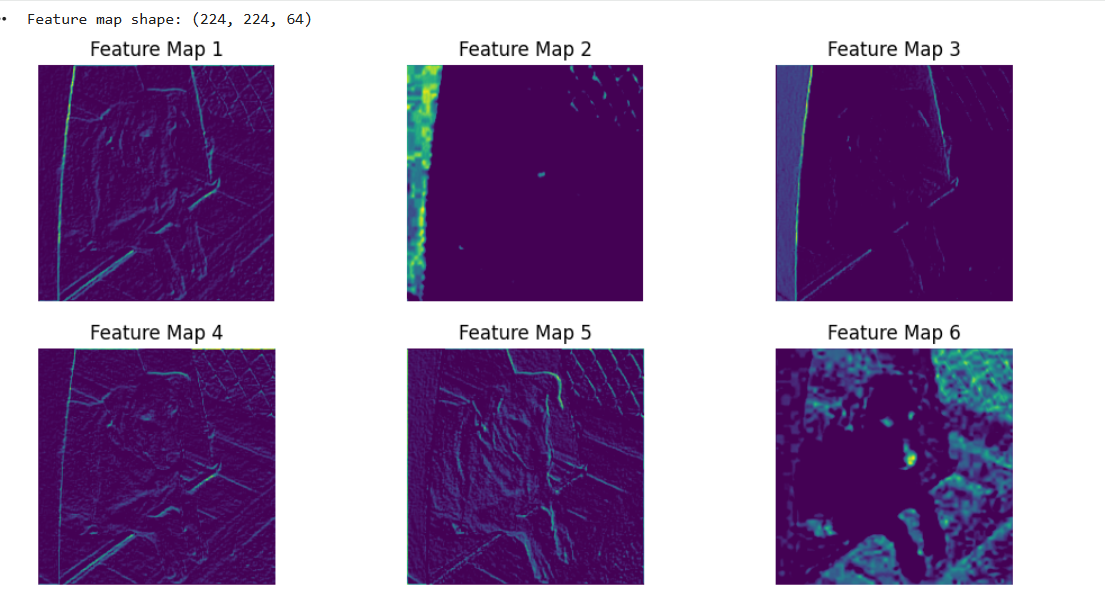

**Prediction Results**
The pretrained model produced the top three predictions for the input image. The predictions were based on patterns learned from the ImageNet dataset.

Example prediction output:

Rhodesian Ridgeback – 49.72%

Redbone – 33.93%

Irish Terrier – 3.14%

The predictions indicate that the model identified features related to dog breeds such as fur texture, ear shape, and facial structure.

Early CNN layers detect simple patterns such as edges, lines, and textures. Deeper layers combine these basic patterns to identify more complex features like object parts and full objects.

Pretrained models are widely used in industry because they save training time and require less data. Instead of training a deep network from scratch, developers can reuse knowledge learned from large datasets.

Transfer learning allows models trained on large datasets to be applied to new tasks efficiently, improving performance and reducing computational cost.

**Conclusion**

This project demonstrated how a pretrained CNN model can be used for image analysis and feature visualization. The results show that CNNs learn hierarchical features, starting from simple patterns in early layers to complex object representations in deeper layers. Using pretrained models and transfer learning enables efficient and accurate image analysis without the need for extensive training.